# Bank Customer Term-Deposit Subscription Prediction

## Using Machine Learning

---

### Problem Statement

Banks conduct direct marketing campaigns (phone calls) to encourage customers to subscribe to term deposits. Contacting every customer is inefficient and costly. This project analyses customer demographics and campaign-related data from a Portuguese bank and develops a machine-learning classification model to **predict whether a customer is likely to subscribe to a term deposit** (`y = yes / no`).

Identifying likely subscribers in advance allows the bank to focus its outreach on high-probability customers, improving campaign efficiency and reducing unnecessary contact.

### Objectives

1. Perform thorough exploratory data analysis (EDA) on the bank marketing dataset.
2. Build a reproducible preprocessing pipeline using `scikit-learn`.
3. Train and compare three classification models: Logistic Regression, Decision Tree, Random Forest.
4. Evaluate models using multiple metrics (Accuracy, Precision, Recall, F1, ROC-AUC) with careful attention to class imbalance.
5. Select and justify the final model based on the project objective.
6. Save the final model for reuse.

### Dataset

**Source:** UCI Machine Learning Repository â€” Bank Marketing Dataset (Moro et al., 2014)  
**File:** `dataset/bank-full.csv` â€” 45,211 rows, 17 columns, semicolon-delimited  
**Reference:** https://archive.ics.uci.edu/ml/datasets/bank+marketing

---
## 1. Setup

In [1]:
import sys
import os
from pathlib import Path

# Ensure src/ is on the path when running from notebooks/
notebook_dir = Path(os.getcwd())
if notebook_dir.name == "notebooks":
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import warnings
warnings.filterwarnings("ignore")

import matplotlib
matplotlib.use("Agg")  # non-interactive backend; figures displayed via IPython display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
from IPython.display import Image, display

print(f"Python: {sys.version.split()[0]}")
print(f"Project root: {project_root}")

Python: 3.12.8
Project root: C:\Users\shyam\OneDrive\Desktop\Bank_Term_Deposit_Prediction


---
## 2. Data Loading and Initial Inspection

In [2]:
from src.data_loader import load_data

df = load_data()

Loaded 45,211 rows Ã— 17 columns from 'bank-full.csv'
Dropped 'duration' column (only known after call ends â€” data leakage).
Target 'y' encoded: {0: 39922, 1: 5289}
Added 'was_contacted': 8,257 previously contacted (18.3%), 36,954 never contacted (pdays == -1).
Note: 'pdays' original values preserved intact (including -1 sentinel).

--- 'unknown' value counts by column ---
   column  unknown_count unknown_pct
      job            288        0.6%
education           1857        4.1%
  contact          13020       28.8%
 poutcome          36959       81.7%
Note: 'unknown' values are retained as valid category levels. They may carry predictive signal and are NOT treated as NaN.


In [3]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (45211, 17)

Data types:
age               int64
job              object
marital          object
education        object
default          object
balance           int64
housing          object
loan             object
contact          object
day               int64
month            object
campaign          int64
pdays             int64
previous          int64
poutcome         object
y                 int64
was_contacted     int64
dtype: object

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y,was_contacted
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,0,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,0,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,0,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,0,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,0,0


In [4]:
print("Descriptive statistics â€” numeric features:")
df.describe()

Descriptive statistics â€” numeric features:


,age,balance,day,campaign,pdays,previous,y,was_contacted
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,2.763841,40.197828,0.580323,0.116985,0.182633
std,10.618762,3044.765829,8.322476,3.098021,100.128746,2.303441,0.321406,0.386369
min,18.000000,-8019.000000,1.000000,1.000000,-1.000000,0.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,1.000000,-1.000000,0.000000,0.000000,0.000000
50%,39.000000,448.000000,16.000000,2.000000,-1.000000,0.000000,0.000000,0.000000
75%,48.000000,1428.000000,21.000000,3.000000,-1.000000,0.000000,0.000000,0.000000
max,95.000000,102127.000000,31.000000,63.000000,871.000000,275.000000,1.000000,1.000000


In [5]:
print("Missing values (NaN):")
print(df.isnull().sum())
print("\nNote: There are no NaN values. 'unknown' values in categorical columns are literal strings.")

Missing values (NaN):
age              0
job              0
marital          0
education        0
default          0
balance          0
housing          0
loan             0
contact          0
day              0
month            0
campaign         0
pdays            0
previous         0
poutcome         0
y                0
was_contacted    0
dtype: int64

Note: There are no NaN values. 'unknown' values in categorical columns are literal strings.


---
## 3. Key Data Decisions

### 3.1 `duration` Column â€” Data Leakage

The `duration` column records the length of the last phone call in seconds. This information is **only available after the call has already taken place**, meaning it cannot be known before contacting a customer. Using it as a predictor would inflate model performance artificially (data leakage). The column was dropped immediately on data load.

### 3.2 `pdays` Sentinel Value

`pdays` records the number of days since the customer was last contacted in a previous campaign. A value of **-1** means the customer was **never previously contacted** â€” it is a meaningful sentinel, not a missing value.

We preserve `pdays` exactly as loaded and add a separate binary feature `was_contacted` (1 if `pdays != -1`, else 0) to make this distinction explicit for the model.

### 3.3 `"unknown"` Categorical Values

Several categorical columns contain the literal string `"unknown"`. These are **not NaN values** and are retained as a valid category level. They carry predictive signal â€” especially in `contact` and `poutcome` â€” and would be lost if imputed away.

In [6]:
from src.data_loader import get_unknown_audit

audit = get_unknown_audit(df)
print("'unknown' string counts per column:")
print(audit.to_string(index=False))

'unknown' string counts per column:
   column  unknown_count unknown_pct
      job            288        0.6%
education           1857        4.1%
  contact          13020       28.8%
 poutcome          36959       81.7%


In [7]:
# pdays inspection
print("pdays value distribution:")
print(f"  Never contacted (pdays == -1): {(df['pdays'] == -1).sum():,} rows ({(df['pdays'] == -1).mean()*100:.1f}%)")
print(f"  Previously contacted (pdays >= 0): {(df['pdays'] >= 0).sum():,} rows")
print(f"  pdays range (contacted only): {df.loc[df['pdays'] >= 0, 'pdays'].min()} to {df.loc[df['pdays'] >= 0, 'pdays'].max()} days")
print(f"\nwas_contacted distribution: {df['was_contacted'].value_counts().to_dict()}")

pdays value distribution:


  Never contacted (pdays == -1): 36,954 rows (81.7%)
  Previously contacted (pdays >= 0): 8,257 rows
  pdays range (contacted only): 1 to 871 days

was_contacted distribution: {0: 36954, 1: 8257}


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable â€” Class Imbalance

The target variable `y` is highly imbalanced. Only approximately **11.7%** of customers subscribed to a term deposit. This imbalance must be accounted for in model design and evaluation â€” accuracy alone would be misleading.

In [8]:
from src.eda import plot_target_distribution

fig = plot_target_distribution(df)
display(fig)
plt.close(fig)

print(f"\nClass distribution:")
counts = df['y'].value_counts()
for val, count in counts.items():
    label = 'Yes (subscribed)' if val == 1 else 'No (did not subscribe)'
    print(f"  {label}: {count:,} ({count/len(df)*100:.1f}%)")

Saved: C:\Users\shyam\OneDrive\Desktop\Bank_Term_Deposit_Prediction\outputs\figures\01_target_distribution.png


<Figure size 720x480 with 1 Axes>


Class distribution:
  No (did not subscribe): 39,922 (88.3%)
  Yes (subscribed): 5,289 (11.7%)


### 4.2 'unknown' Values Audit

In [9]:
from src.eda import plot_unknown_audit

fig = plot_unknown_audit(df)
display(fig)
plt.close(fig)

Saved: C:\Users\shyam\OneDrive\Desktop\Bank_Term_Deposit_Prediction\outputs\figures\07_unknown_audit.png


<Figure size 960x360 with 1 Axes>

**Observation:** `poutcome` has ~81.7% `"unknown"` values (customers who were never previously contacted), and `contact` has ~28.8%. These are retained as explicit categories since the `"unknown"` label itself may be informative.

### 4.3 Numeric Feature Distributions

In [10]:
from src.eda import plot_numeric_distributions, plot_numeric_boxplots

fig = plot_numeric_distributions(df)
display(fig)
plt.close(fig)

Saved: C:\Users\shyam\OneDrive\Desktop\Bank_Term_Deposit_Prediction\outputs\figures\02_numeric_distributions.png


<Figure size 1800x960 with 6 Axes>

In [11]:
fig = plot_numeric_boxplots(df)
display(fig)
plt.close(fig)

Saved: C:\Users\shyam\OneDrive\Desktop\Bank_Term_Deposit_Prediction\outputs\figures\08_numeric_boxplots.png


<Figure size 1440x960 with 4 Axes>

**Observations:**
- `balance` has a wide range with many outliers and can be negative.
- `campaign` is highly right-skewed; most customers were contacted 1â€“3 times.
- `pdays` distribution is bimodal: a large spike at -1 (never contacted) and a distribution of actual day-counts for those who were.
- Subscribers tend to have slightly higher `balance` and fewer `campaign` contacts.

### 4.4 `pdays` Sentinel Analysis

In [12]:
from src.eda import plot_pdays_analysis

fig = plot_pdays_analysis(df)
display(fig)
plt.close(fig)

Saved: C:\Users\shyam\OneDrive\Desktop\Bank_Term_Deposit_Prediction\outputs\figures\05_pdays_analysis.png


<Figure size 1440x600 with 2 Axes>

**Observation:** Customers who were previously contacted have a noticeably higher subscription rate than those who were never contacted. This confirms that `was_contacted` and `pdays` are meaningful predictors.

### 4.5 Categorical Feature Distributions

In [13]:
from src.eda import plot_categorical_distributions

fig = plot_categorical_distributions(df)
display(fig)
plt.close(fig)

Saved: C:\Users\shyam\OneDrive\Desktop\Bank_Term_Deposit_Prediction\outputs\figures\03_categorical_distributions.png


<Figure size 1680x4320 with 9 Axes>

**Key observations:**
- `poutcome = success` strongly predicts subscription.
- `contact = cellular` has a higher subscription rate than `telephone` or `unknown`.
- `education = tertiary` and `job = student`/`retired` show higher subscription rates.
- Month `mar`, `sep`, `oct`, `dec` show elevated subscription rates (smaller campaigns).

### 4.6 Subscription Rate by Individual Features

In [14]:
from src.eda import plot_subscription_by_feature

for feature in ["job", "month", "poutcome"]:
    fig = plot_subscription_by_feature(df, feature)
    display(fig)
    plt.close(fig)

Saved: C:\Users\shyam\OneDrive\Desktop\Bank_Term_Deposit_Prediction\outputs\figures\06_sub_rate_job.png


<Figure size 1152x480 with 1 Axes>

Saved: C:\Users\shyam\OneDrive\Desktop\Bank_Term_Deposit_Prediction\outputs\figures\06_sub_rate_month.png


<Figure size 1152x480 with 1 Axes>

Saved: C:\Users\shyam\OneDrive\Desktop\Bank_Term_Deposit_Prediction\outputs\figures\06_sub_rate_poutcome.png


<Figure size 720x480 with 1 Axes>

### 4.7 Correlation Heatmap

In [15]:
from src.eda import plot_correlation_heatmap

fig = plot_correlation_heatmap(df)
display(fig)
plt.close(fig)

Saved: C:\Users\shyam\OneDrive\Desktop\Bank_Term_Deposit_Prediction\outputs\figures\04_correlation_heatmap.png


<Figure size 1200x960 with 2 Axes>

**Observation:** Numeric features are mostly weakly correlated with each other. `pdays` and `was_contacted` have a moderate correlation (expected, since `was_contacted` is derived from `pdays`). `previous` and `was_contacted` are also correlated. The target `y` shows the highest correlation with `was_contacted` and `pdays` among numeric features.

---
## 5. Feature Engineering and Preprocessing Pipeline

The preprocessing pipeline is built using scikit-learn's `ColumnTransformer` to keep numeric and categorical paths separated and prevent data leakage.

**Numeric features** (`age`, `balance`, `day`, `campaign`, `pdays`, `previous`, `was_contacted`):
- `SimpleImputer(strategy="median")` â€” handles any rare NaNs
- `StandardScaler()` â€” normalises to zero mean and unit variance
- `pdays` values are preserved intact (including -1); `StandardScaler` normalises the full range

**Categorical features** (`job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`):
- `SimpleImputer(strategy="most_frequent")` â€” handles any rare NaNs
- `OneHotEncoder(handle_unknown="ignore")` â€” creates indicator columns per category level; `"unknown"` strings produce their own indicator column (e.g., `poutcome_unknown`)
- `month` is one-hot encoded as a nominal categorical (no ordinal assumption imposed)

In [16]:
from src.preprocessing import (
    NUMERIC_FEATURES, CATEGORICAL_FEATURES,
    build_preprocessor, get_X_y, get_feature_names
)

print(f"Numeric features ({len(NUMERIC_FEATURES)}):")
print(NUMERIC_FEATURES)
print(f"\nCategorical features ({len(CATEGORICAL_FEATURES)}):")
print(CATEGORICAL_FEATURES)

Numeric features (7):
['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'was_contacted']

Categorical features (9):
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [17]:
X, y = get_X_y(df)

# Demonstrate the preprocessor on the full dataset (for inspection only)
preprocessor_demo = build_preprocessor()
X_transformed = preprocessor_demo.fit_transform(X)
feature_names = get_feature_names(preprocessor_demo)

print(f"Original X shape:    {X.shape}")
print(f"Transformed X shape: {X_transformed.shape}")
print(f"Total features after OHE: {len(feature_names)}")
print("\nSample feature names:")
print("  Numeric:", feature_names[:7])
print("  Categorical (first 10):", feature_names[7:17])

Original X shape:    (45211, 16)
Transformed X shape: (45211, 51)
Total features after OHE: 51

Sample feature names:
  Numeric: ['num__age', 'num__balance', 'num__day', 'num__campaign', 'num__pdays', 'num__previous', 'num__was_contacted']
  Categorical (first 10): ['cat__job_admin.', 'cat__job_blue-collar', 'cat__job_entrepreneur', 'cat__job_housemaid', 'cat__job_management', 'cat__job_retired', 'cat__job_self-employed', 'cat__job_services', 'cat__job_student', 'cat__job_technician']


---
## 6. Train / Test Split

A **stratified 80/20 split** is used. Stratification ensures the minority class (~11.7% positive rate) is proportionally represented in both training and test sets, preventing the test set from being unrepresentatively easy or hard.

In [18]:
from src.train import split_data

X_train, X_test, y_train, y_test = split_data(df)

print(f"\nClass balance verification:")
print(f"  Train positive rate: {y_train.mean():.4f}")
print(f"  Test  positive rate: {y_test.mean():.4f}")
print("  Stratification confirmed â€” rates match.")

Train: 36,168 rows  |  Test: 9,043 rows  |  Positive rate â€” train: 0.117  test: 0.117

Class balance verification:
  Train positive rate: 0.1170
  Test  positive rate: 0.1170
  Stratification confirmed â€” rates match.


---
## 7. Model Training

Three classifiers are trained, each wrapped in a `Pipeline(preprocessor + estimator)`. All use `class_weight="balanced"` to compensate for the ~88/12% class imbalance.

| Model | Key Parameters |
|-------|----------------|
| Logistic Regression | `class_weight="balanced"`, `max_iter=1000`, `solver="lbfgs"` |
| Decision Tree | `class_weight="balanced"` |
| Random Forest | `class_weight="balanced"`, `n_estimators=100` |

In [19]:
from src.train import train_all_models

pipelines, results_df = train_all_models(X_train, y_train, X_test, y_test)


Training Logistic Regression...



  Logistic Regression
  accuracy    : 0.7553
  precision   : 0.2667
  recall      : 0.6238
  f1          : 0.3736
  roc_auc     : 0.7722

              precision    recall  f1-score   support

          No       0.94      0.77      0.85      7985
         Yes       0.27      0.62      0.37      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043

Saved confusion matrix: cm_logistic_regression.png

Training Decision Tree...



  Decision Tree
  accuracy    : 0.8394
  precision   : 0.3072
  recall      : 0.2968
  f1          : 0.3019
  roc_auc     : 0.6041

              precision    recall  f1-score   support

          No       0.91      0.91      0.91      7985
         Yes       0.31      0.30      0.30      1058

    accuracy                           0.84      9043
   macro avg       0.61      0.60      0.61      9043
weighted avg       0.84      0.84      0.84      9043

Saved confusion matrix: cm_decision_tree.png

Training Random Forest...



  Random Forest
  accuracy    : 0.8800
  precision   : 0.4849
  recall      : 0.4102
  f1          : 0.4444
  roc_auc     : 0.7935

              precision    recall  f1-score   support

          No       0.92      0.94      0.93      7985
         Yes       0.48      0.41      0.44      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.68      0.69      9043
weighted avg       0.87      0.88      0.88      9043



Saved confusion matrix: cm_random_forest.png


---
## 8. Model Evaluation and Comparison

### 8.1 Metrics Summary Table

In [20]:
print("\n=== Model Evaluation Results ===")
print(results_df.to_string(float_format="{:.4f}".format))


=== Model Evaluation Results ===
                     Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                           
Logistic Regression    0.7553     0.2667  0.6238 0.3736   0.7722
Decision Tree          0.8394     0.3072  0.2968 0.3019   0.6041
Random Forest          0.8800     0.4849  0.4102 0.4444   0.7935


In [21]:
# Styled table for display
results_df.style.format("{:.4f}").highlight_max(axis=0, color="#c6efce")

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.7553,0.2667,0.6238,0.3736,0.7722
Decision Tree,0.8394,0.3072,0.2968,0.3019,0.6041
Random Forest,0.8800,0.4849,0.4102,0.4444,0.7935


### 8.2 Confusion Matrices


Logistic Regression


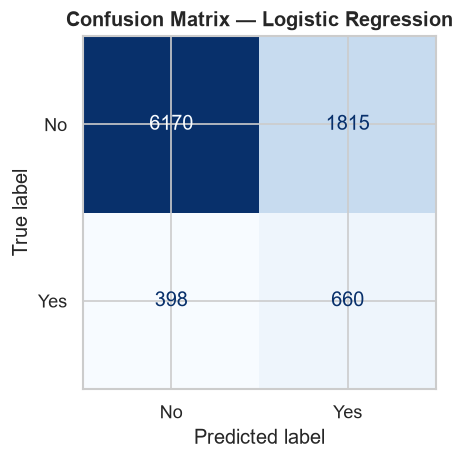


Decision Tree


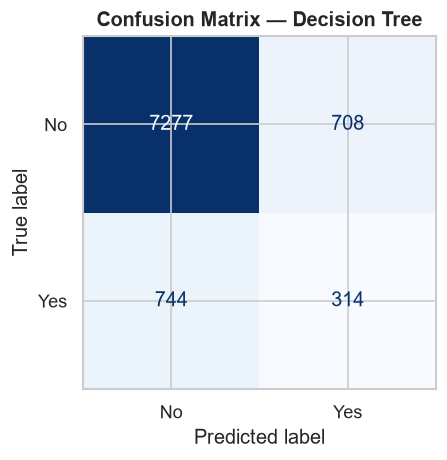


Random Forest


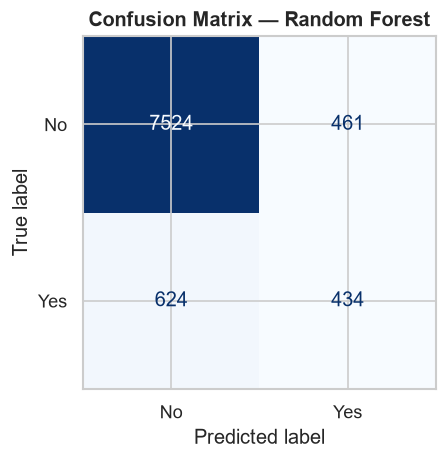

In [22]:
from src.config import FIGURES_DIR

for model_name in pipelines.keys():
    fname = model_name.lower().replace(" ", "_")
    img_path = FIGURES_DIR / f"cm_{fname}.png"
    if img_path.exists():
        print(f"\n{model_name}")
        display(Image(filename=str(img_path)))

### 8.3 ROC Curves

In [23]:
from src.train import plot_roc_curves

fig = plot_roc_curves(pipelines, X_test, y_test)
display(fig)
plt.close(fig)

Saved ROC curves: roc_curves.png


<Figure size 960x720 with 1 Axes>

### 8.4 Metrics Comparison Chart

In [24]:
from src.train import plot_metrics_comparison

fig = plot_metrics_comparison(results_df)
display(fig)
plt.close(fig)

Saved metrics comparison: metrics_comparison.png


<Figure size 1200x600 with 1 Axes>

---
## 9. Model Selection and Justification

### Project Objective Reminder

The goal is to help the bank **identify customers likely to subscribe to a term deposit before contacting them**. In this context:

- A **False Negative** (predicting No, but the customer would have subscribed) means a missed opportunity â€” a potential subscriber is not contacted.
- A **False Positive** (predicting Yes, but the customer would not subscribe) means wasted effort â€” the bank contacts someone who won't convert.

Given that the bank's primary motivation is **campaign efficiency** (reduce wasted contacts) while still **capturing likely subscribers**, a good model needs to balance Recall (catching real subscribers) and Precision (not flooding the campaign with non-subscribers). **F1-score** â€” the harmonic mean of Precision and Recall â€” is therefore the most relevant single metric, supplemented by **ROC-AUC** as a threshold-independent measure of discriminative ability.

Accuracy is an unreliable metric here because a model that predicts "No" for every customer achieves ~88% accuracy without identifying a single subscriber.

### Comparison Analysis

In [25]:
print("Model Comparison (sorted by F1):")
print(results_df.sort_values("F1", ascending=False).to_string(float_format="{:.4f}".format))

print("\nModel Comparison (sorted by ROC-AUC):")
print(results_df.sort_values("ROC-AUC", ascending=False).to_string(float_format="{:.4f}".format))

Model Comparison (sorted by F1):
                     Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                           
Random Forest          0.8800     0.4849  0.4102 0.4444   0.7935
Logistic Regression    0.7553     0.2667  0.6238 0.3736   0.7722
Decision Tree          0.8394     0.3072  0.2968 0.3019   0.6041

Model Comparison (sorted by ROC-AUC):
                     Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                           
Random Forest          0.8800     0.4849  0.4102 0.4444   0.7935
Logistic Regression    0.7553     0.2667  0.6238 0.3736   0.7722
Decision Tree          0.8394     0.3072  0.2968 0.3019   0.6041


### Selection: Random Forest

Based on the evaluation results:

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|----------|-----------|--------|----|---------|
| Logistic Regression | 0.7553 | 0.2667 | 0.6238 | 0.3736 | 0.7722 |
| Decision Tree | 0.8394 | 0.3072 | 0.2968 | 0.3019 | 0.6041 |
| **Random Forest** | **0.8800** | **0.4849** | **0.4102** | **0.4444** | **0.7935** |

**Random Forest is selected as the final model** for the following reasons:

1. **Highest F1-score (0.4444):** The best balance between Precision and Recall, making it the most useful for the campaign efficiency objective.

2. **Highest ROC-AUC (0.7935):** Best overall discriminative ability across all classification thresholds, indicating the model ranks subscribers above non-subscribers more reliably.

3. **Highest Precision (0.4849):** Nearly half of the customers it flags as likely subscribers actually do subscribe â€” almost double the precision of Logistic Regression. This directly reduces wasted contacts.

4. **Reasonable Recall (0.4102):** It captures ~41% of actual subscribers, compared to the Decision Tree's 30%. The Logistic Regression achieves higher recall (62%) but at the cost of very low precision (27%) â€” it would flood the campaign list with unlikely subscribers.

5. **Decision Tree underperforms significantly:** Its ROC-AUC of 0.6041 and F1 of 0.3019 indicate poor generalisation, likely due to overfitting.

**Trade-off note:** If the bank's strategy shifts to maximising subscriber capture at the cost of more wasted contacts (e.g., in a low-cost digital campaign), Logistic Regression's higher Recall could be preferred. For a standard phone-call campaign with significant per-contact cost, **Random Forest** provides the best overall balance.

---
## 10. Save Final Model

In [26]:
from src.utils import save_model, load_model

final_model_name = "Random Forest"
final_pipeline = pipelines[final_model_name]

saved_path = save_model(final_pipeline, "final_model.pkl")
print(f"\nFinal model ({final_model_name}) saved to: {saved_path}")

Model saved: C:\Users\shyam\OneDrive\Desktop\Bank_Term_Deposit_Prediction\models\final_model.pkl

Final model (Random Forest) saved to: C:\Users\shyam\OneDrive\Desktop\Bank_Term_Deposit_Prediction\models\final_model.pkl


In [27]:
# Verify: load the saved model and confirm it produces identical predictions
loaded_model = load_model("final_model.pkl")

preds_original = final_pipeline.predict(X_test.head(10))
preds_loaded = loaded_model.predict(X_test.head(10))

assert list(preds_original) == list(preds_loaded), "Predictions differ â€” model save/load failed!"
print("Save/load verification passed â€” loaded model produces identical predictions.")
print(f"Sample predictions: {preds_loaded}")

Model loaded: C:\Users\shyam\OneDrive\Desktop\Bank_Term_Deposit_Prediction\models\final_model.pkl
Save/load verification passed â€” loaded model produces identical predictions.
Sample predictions: [0 0 0 0 0 0 0 1 0 0]


---
## 11. Conclusions

### Summary of Findings

1. **Class Imbalance:** Only ~11.7% of customers subscribed. Accuracy alone is a misleading metric. `class_weight="balanced"` was applied to all models.

2. **Data Leakage Prevention:** The `duration` column was removed from all models â€” it is only known after the call and cannot be used for prospective prediction.

3. **`pdays` Sentinel:** The `-1` value in `pdays` is a meaningful indicator of "never previously contacted" customers. It was preserved intact and complemented by a new `was_contacted` binary feature.

4. **`"unknown"` Values:** Retained as explicit category levels across four columns (`job`, `education`, `contact`, `poutcome`). Notably, `poutcome_unknown` is likely the most common value and carries predictive information.

5. **EDA Insights:**
   - Customers previously successfully contacted (`poutcome = success`) have the highest subscription rate.
   - Cellular contact method is associated with higher subscription rates.
   - Campaigns in March, September, October, and December tend to have higher per-contact success rates.
   - Students and retired customers are more likely to subscribe.

6. **Final Model:** Random Forest â€” best F1 (0.4444), best ROC-AUC (0.7935), and best Precision (0.4849) among the three models. Suitable for a realistic phone-call marketing campaign where both subscriber capture and contact efficiency matter.

### Limitations

- The dataset reflects one bank's campaigns from 2008â€“2010. Results may not generalise to other banks or time periods.
- Hyperparameter tuning (grid search / cross-validation) was not performed â€” there is room to improve all models through tuning.
- Advanced models (Gradient Boosting, XGBoost) may achieve higher performance and are worth exploring.
- The threshold for classification (default 0.5) was not optimised. Adjusting the threshold could improve Recall at the cost of Precision depending on business needs.